# 使用 PyTorch 在 MNIST 数据集上进行逻辑回归

**逻辑回归（Logistic Regression）**既可以用来描述数据，也可以用来解释数据中各个二值变量、类别变量、顺序变量、距离变量、比率变量之间的关系[1]。下图展示了**逻辑回归**与**线性回归**的区别。

![Taken from [https://www.sciencedirect.com/topics/nursing-and-health-professions/logistic-regression-analysis](https://www.sciencedirect.com/topics/nursing-and-health-professions/logistic-regression-analysis)](https://cdn-images-1.medium.com/max/2000/1*xFhICZgdr2VEZQ-C4FLUEA.jpeg)

本文将展示如何使用 PyTorch 编写逻辑回归模型。

我们将尝试在 MNIST 数据集上解决分类问题。首先，导入我们所需要的所有库：

In [6]:
import torch
from torch.autograd import Variable
import torchvision.transforms as transforms
import torchvision.datasets as dsets

在创建模型前，我喜欢列一个如下的步骤表。PyTorch 官网[2]上也有这个步骤列表：

In [7]:
# 第一步：加载数据集
# 第二步：使数据集可迭代
# 第三步：创建模型类
# 第四步：将模型类实例化
# 第五步：实例化 Loss 类
# 第六步：实例化优化器类
# 第七步：训练模型

下面我们将一步步完成上述的步骤。

### 加载数据集

我们使用 **torchvision.datasets** 来加载数据集。这个库中包含了几乎全部的用于机器学习的流行数据集。在[3]中可以看到完整的数据集列表。

In [8]:
train_dataset = dsets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=False)
test_dataset = dsets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

### 使数据集可迭代

我们利用 DataLoader 类，使用以下代码来让我们的数据集可被迭代：

In [9]:
batch_size = 100
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### 创建模型类

现在，我们将创建一个用来定义逻辑回归模型结构的类：

In [10]:
class LogisticRegression(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):
        outputs = self.linear(x)
        return outputs

### 将模型类实例化

在将模型类实例化之前，我们先初始化如下所示的参数：

In [11]:
batch_size = 100
n_iters = 3000
epochs = n_iters / (len(train_dataset) / batch_size)
input_dim = 784
output_dim = 10
lr_rate = 0.001

然后，就能初始化我们的逻辑回归模型了：

In [12]:
model = LogisticRegression(input_dim, output_dim)

### 实例化 Loss 类

我们使用交叉熵损失来计算 loss：

In [13]:
criterion = torch.nn.CrossEntropyLoss() # 计算 softmax 分布之上的交叉熵损失

### 实例化优化器类

优化器（optimizer）就是我们即将使用的学习算法。在本例中，我们将使用随机梯度下降（SGD）作为优化器：

In [14]:
optimizer = torch.optim.SGD(model.parameters(), lr=lr_rate)

### 训练模型

这就是最后一步了。我们将用以下的代码来训练模型：

In [15]:
best_accuracy = 0
iter = 0
for epoch in range(int(epochs)):
    for i, (images, labels) in enumerate(train_loader):
        images = Variable(images.view(-1, 28 * 28))
        labels = Variable(labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        iter+=1
        if iter%500==0:
            # 计算准确率
            correct = 0
            total = 0
            for images, labels in test_loader:
                images = Variable(images.view(-1, 28*28))
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total+= labels.size(0)
                # 如果用的是 GPU，则要把预测值和标签都取回 CPU，才能用 Python 来计算
                correct+= (predicted == labels).sum()
            accuracy = 100 * correct/total
            print("Iteration: {}. Loss: {}. Accuracy: {}.".format(iter, loss.item(), accuracy))
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                torch.save(model.state_dict(), './model/best_logis_regress_model.pth')
                print("Saved best model with accuracy: {}".format(best_accuracy))

Iteration: 500. Loss: 1.8584293127059937. Accuracy: 64.41000366210938.
Saved best model with accuracy: 64.41000366210938
Iteration: 1000. Loss: 1.5470352172851562. Accuracy: 74.7699966430664.
Saved best model with accuracy: 74.7699966430664
Iteration: 1500. Loss: 1.3748409748077393. Accuracy: 78.36000061035156.
Saved best model with accuracy: 78.36000061035156
Iteration: 2000. Loss: 1.2659498453140259. Accuracy: 79.95999908447266.
Saved best model with accuracy: 79.95999908447266
Iteration: 2500. Loss: 1.0985536575317383. Accuracy: 81.38999938964844.
Saved best model with accuracy: 81.38999938964844
Iteration: 3000. Loss: 1.0404052734375. Accuracy: 82.41999816894531.
Saved best model with accuracy: 82.41999816894531


在训练时，这个模型只需要进行 3000 次迭代就能达到 **82%** 的准确率。你可以试着继续调整一下参数，看看还能不能把准确率再调高一点。

如果你想加深对在 PyTorch 中实现逻辑回归的理解，可以把上面的模型应用于任何分类问题。比如，你可以训练一个逻辑回归模型来对你最喜爱的**漫威英雄**的图像做个分类（有一半已经化灰了，所以做分类应该不是很难）:)

### 推理 (Inference)

现在我们使用训练好的模型对测试集中的一张图像进行分类预测。

Loaded best model weights from best_model.pth


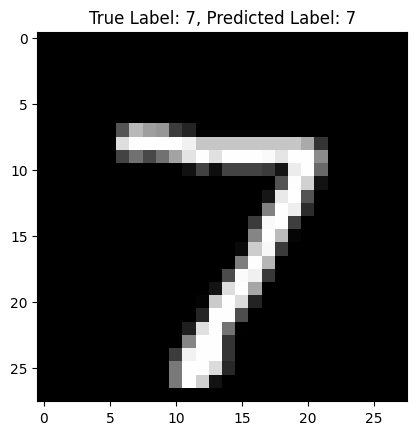

The model predicted this image as digit 7


In [16]:
import matplotlib.pyplot as plt

# 加载测试集中的一张图像
image, label = test_dataset[0]
image_input = Variable(image.view(-1, 28 * 28))

# 将模型设置为评估模式
model.eval()

# 如果保存了最佳模型，则加载权重
try:
    model.load_state_dict(torch.load('./model/best_logis_regress_model.pth'))
    print("Loaded best model weights from best_model.pth")
except FileNotFoundError:
    print("best_model.pth not found, using current model weights")

# 进行推理
with torch.no_grad():
    output = model(image_input)
    _, predicted = torch.max(output.data, 1)

# 可视化结果
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {label}, Predicted Label: {predicted.item()}")
plt.show()

print(f"The model predicted this image as digit {predicted.item()}")

### 权重可视化 (Weight Visualization)

逻辑回归模型的权重矩阵大小为 $10 \times 784$。每一行代表一个数字类别的“模板”。我们将每一行重新排列为 $28 \times 28$ 的图像，以直观地观察模型在识别每个数字时在关注什么。

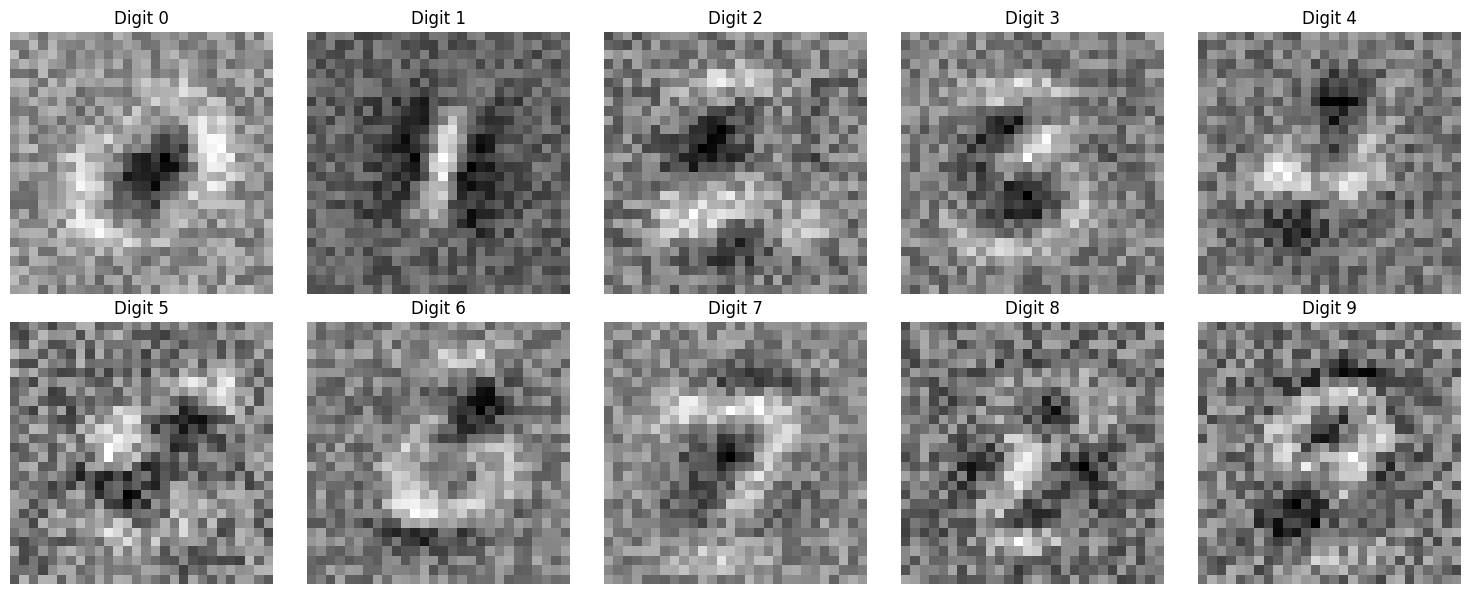

In [18]:
import matplotlib.pyplot as plt

# Load the best model
model.load_state_dict(torch.load('./model/best_logis_regress_model.pth'))
model.eval()

# Extract weights: shape is (10, 784)
weights = model.linear.weight.data

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape each row (784) into 28x28 image
    weight_img = weights[i].reshape(28, 28)
    plt.imshow(weight_img, cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()